## SciPy distribution backends

Use the corresponding `scipy.stats` functions for PDF, CDF, and inverse-CDF calculations:

| Project distribution | SciPy function and parameters |
|---|---|
| Uniform on $[a, b]$ | `uniform(loc=a, scale=b-a)` |
| Semicircle with radius $r$ | `semicircular(loc=0, scale=r)` |
| Normal $(\mu, \sigma)$ | `norm(loc=mu, scale=sigma)` |
| Lognormal from normal $(\mu, \sigma)$ | `lognorm(s=sigma, loc=0, scale=exp(mu))` |
| Exponential with rate $\lambda$ | `expon(loc=0, scale=1/lambda)` |
| Beta $(a, b)$ on $[-1, 1]$ | `beta(a, b, loc=-1, scale=2)` |
| Arcsine on $[-1, 1]$ | `arcsine(loc=-1, scale=2)` |

```python
from scipy.stats import norm

class NormalDistribution(Distribution):

    def pdf(self, x):
        return norm.pdf(x, loc=self.mu, scale=self.sigma)

    def cdf(self, x):
        return norm.cdf(x, loc=self.mu, scale=self.sigma)

    def invcdf(self, p):
        return norm.ppf(p, loc=self.mu, scale=self.sigma)
```

`TranslatedDistribution` may become obsolete.

## Polynomial weights

Two distinct polynomials are orthogonal when their weighted inner product is zero:

$$
\int_I p_m(x)\,p_n(x)\,w(x)\,dx = 0, \qquad m \ne n.
$$

Weights below are given up to a positive constant multiplier.

| Polynomial family | Interval | Weight function $w(x)$ | Matching distribution |
|---|---|---|---|
| Chebyshev $T_n$ (first kind) | $[-1, 1]$ | $\frac{1}{\sqrt{1-x^2}}$ | Arcsine; Beta $(\frac{1}{2}, \frac{1}{2})$ mapped to $[-1, 1]$ |
| Chebyshev $U_n$ (second kind) | $[-1, 1]$ | $\sqrt{1-x^2}$ | Semicircle; Beta $(\frac{3}{2}, \frac{3}{2})$ mapped to $[-1, 1]$ |
| Jacobi $P_n^{(\alpha,\beta)}$ | $[-1, 1]$ | $(1-x)^\alpha(1+x)^\beta$, $\alpha,\beta>-1$ | General Beta $(a,b)$ mapped to $[-1,1]$; this implementation uses $\alpha=b-1$, $\beta=a-1$ |
| Legendre $P_n$ | $[-1, 1]$ | $1$ | Uniform on $[-1, 1]$ |
| Hermite (probabilists') $He_n$ | $(-\infty, \infty)$ | $e^{-x^2/2}$ | Standard normal |
| Laguerre $L_n$ | $[0, \infty)$ | $e^{-x}$ | Exponential with rate $1$ |

Arcsine on [-1, 1]: max abs diff pdf=2.31e-14, cdf=1.00e+00, invcdf=4.44e-16
SemiCircle(1): max abs diff pdf=0.00e+00, cdf=2.22e-16, invcdf=3.17e-01
Beta(2, 5) on [-1, 1]: max abs diff pdf=0.00e+00, cdf=0.00e+00, invcdf=0.00e+00
Uniform(-1, 1): max abs diff pdf=0.00e+00, cdf=0.00e+00, invcdf=0.00e+00
Normal(0, 1): max abs diff pdf=0.00e+00, cdf=0.00e+00, invcdf=0.00e+00
Exponential(1): max abs diff pdf=0.00e+00, cdf=5.55e-17, invcdf=1.11e-16
LogNormal(0, 1): max abs diff pdf=1.11e-16, cdf=0.00e+00, invcdf=0.00e+00


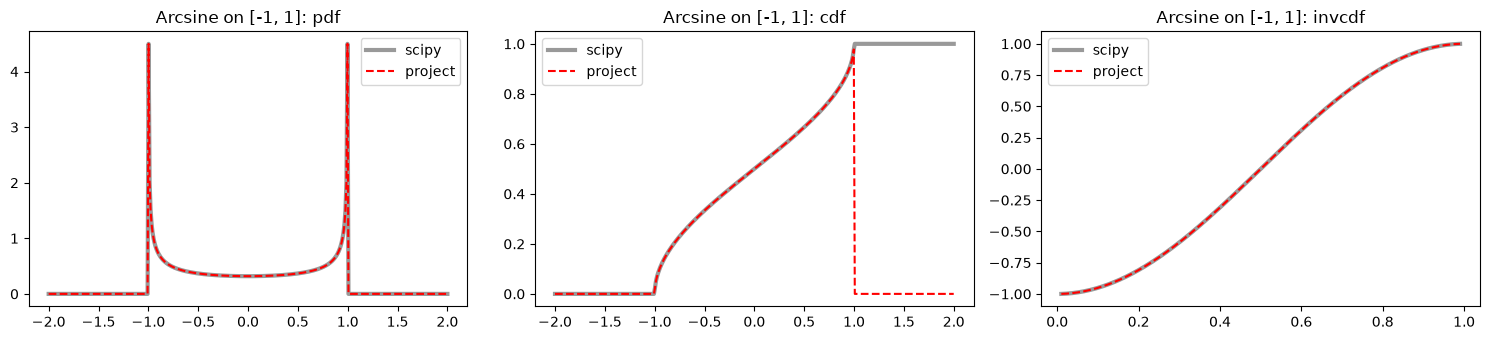

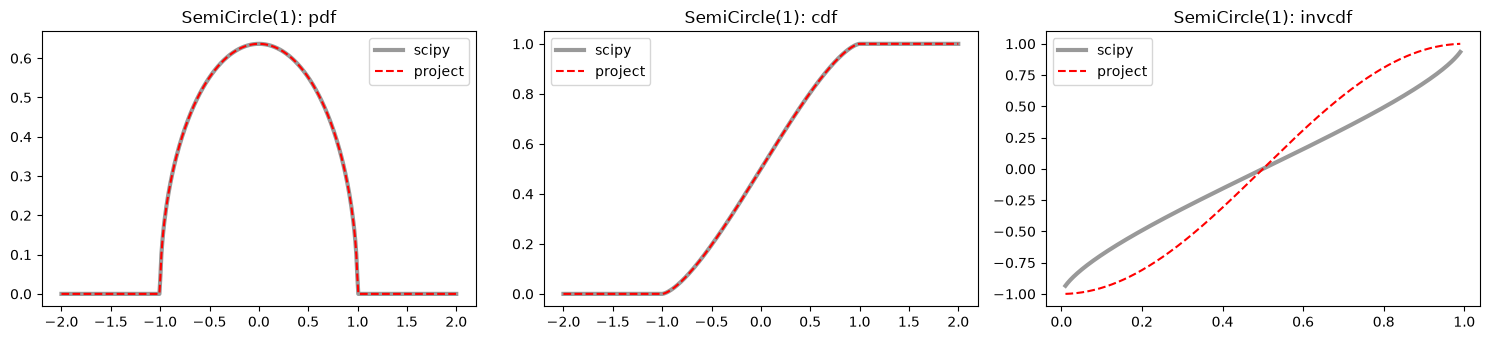

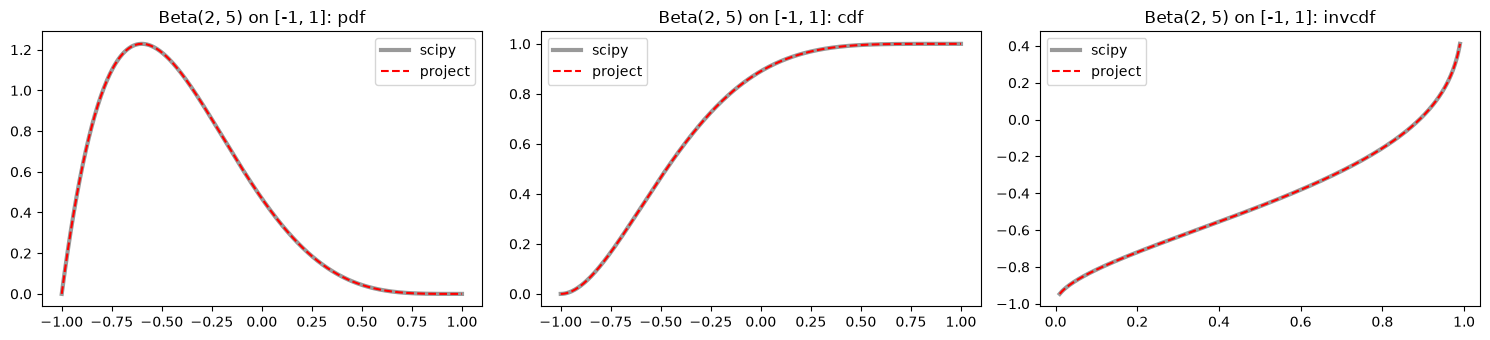

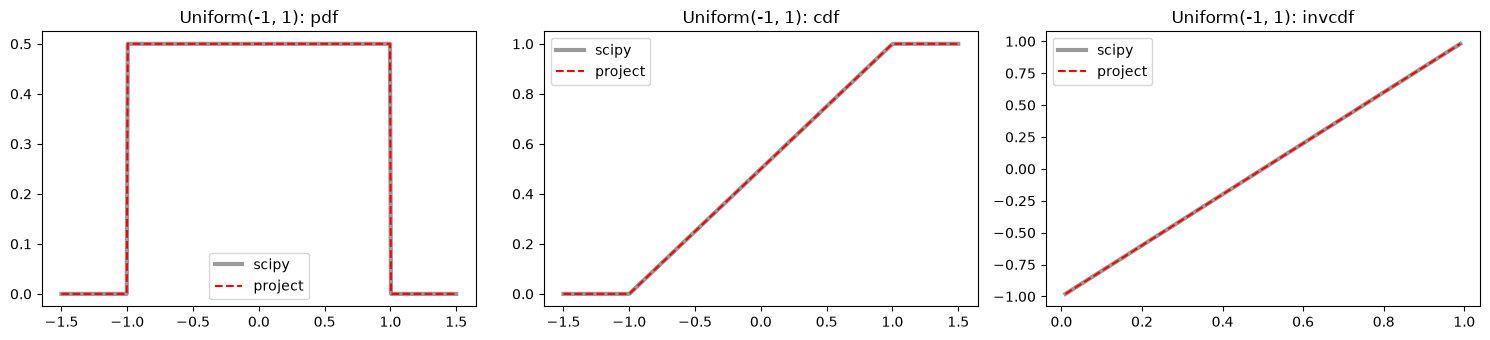

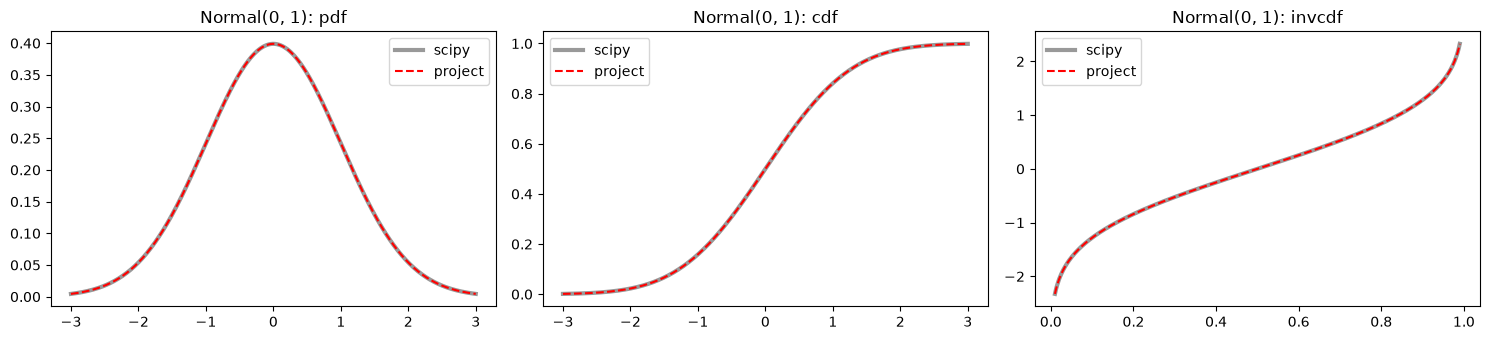

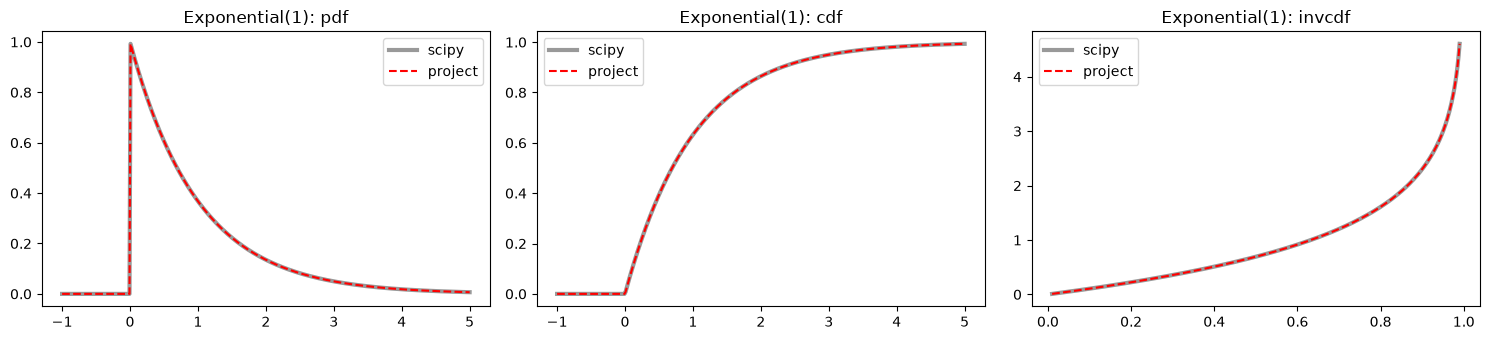

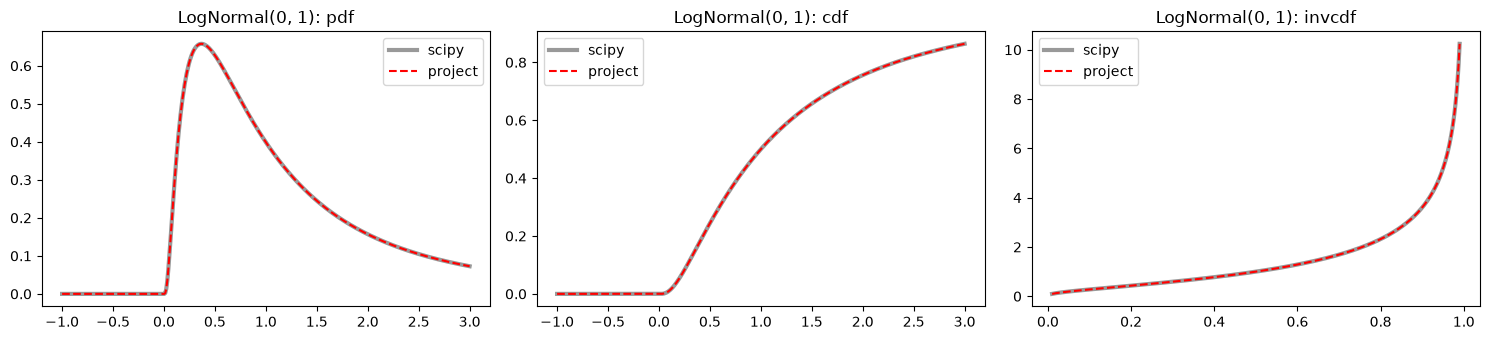

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from uncertain_variables.distributions import (
    ArcsineDistribution, BetaDistribution, ExponentialDistribution, LogNormalDistribution,
    NormalDistribution, SemiCircleDistribution, TranslatedDistribution, UniformDistribution,
)

# (name, project distribution, scipy distribution, plotting range)
cases = [
    ("Arcsine on [-1, 1]", ArcsineDistribution(), stats.arcsine(loc=-1, scale=2), (-2, 2)),
    ("SemiCircle(1)", SemiCircleDistribution(1), stats.semicircular(scale=1), (-2, 2)),
    ("Beta(2, 5) on [-1, 1]", BetaDistribution(2, 5), stats.beta(2, 5, loc=-1, scale=2), (-1, 1)),
    ("Uniform(-1, 1)", UniformDistribution(-1, 1), stats.uniform(loc=-1, scale=2), (-1.5, 1.5)),
    ("Normal(0, 1)", NormalDistribution(0, 1), stats.norm(loc=0, scale=1), (-3, 3)),
    ("Exponential(1)", ExponentialDistribution(1), stats.expon(scale=1), (-1, 5)),
    ("LogNormal(0, 1)", LogNormalDistribution(0, 1), stats.lognorm(s=1, scale=np.exp(0)), (-1, 3)),  
]

def compare(name, d, s, xr):
    x = np.linspace(*xr, 400)
    y = np.linspace(0.01, 0.99, 400)
    fig, ax = plt.subplots(1, 3, figsize=(15, 3.5))
    for a, title, mine, ref, t in [
        (ax[0], "pdf", d.pdf(x), s.pdf(x), x),
        (ax[1], "cdf", d.cdf(x), s.cdf(x), x),
        (ax[2], "invcdf", d.invcdf(y), s.ppf(y), y),
    ]:
        a.plot(t, ref, "k", lw=3, alpha=0.4, label="scipy")
        a.plot(t, mine, "r--", label="project")
        a.set_title(f"{name}: {title}")
        a.legend()
    fig.tight_layout()
    err = [np.max(np.abs(np.asarray(m) - r)) for m, r in
           [(d.pdf(x), s.pdf(x)), (d.cdf(x), s.cdf(x)), (d.invcdf(y), s.ppf(y))]]
    print(f"{name}: max abs diff pdf={err[0]:.2e}, cdf={err[1]:.2e}, invcdf={err[2]:.2e}")

for case in cases:
    compare(*case)
plt.show()


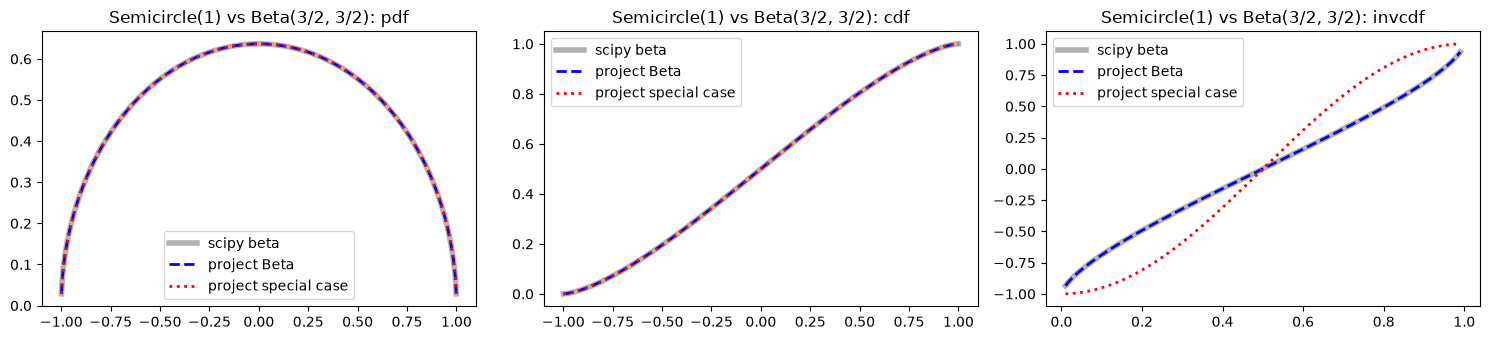

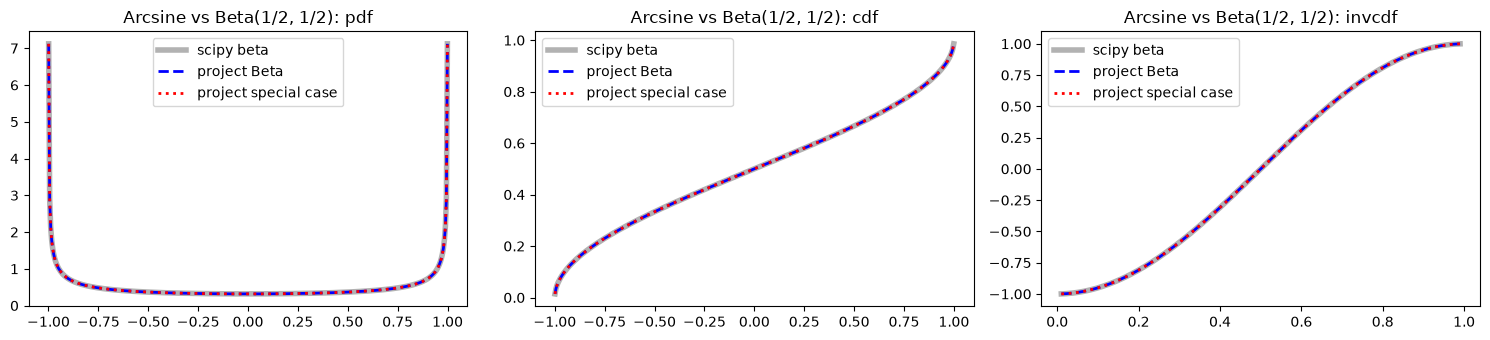

In [4]:
# Semicircle(1) = Beta(3/2, 3/2) and Arcsine = Beta(1/2, 1/2), both on [-1, 1]
special = [
    ("Semicircle(1) vs Beta(3/2, 3/2)", SemiCircleDistribution(1), BetaDistribution(1.5, 1.5),
     stats.beta(1.5, 1.5, loc=-1, scale=2), (-1, 1)),
    ("Arcsine vs Beta(1/2, 1/2)", ArcsineDistribution(), BetaDistribution(0.5, 0.5),
     stats.beta(0.5, 0.5, loc=-1, scale=2), (-1, 1)),
]

for name, special_dist, beta_dist, s, (lo, hi) in special:
    x = np.linspace(lo + 1e-3, hi - 1e-3, 400)
    y = np.linspace(0.01, 0.99, 400)
    fig, ax = plt.subplots(1, 3, figsize=(15, 3.5))
    for a, title, t, curves in [
        (ax[0], "pdf", x, (special_dist.pdf(x), beta_dist.pdf(x), s.pdf(x))),
        (ax[1], "cdf", x, (special_dist.cdf(x), beta_dist.cdf(x), s.cdf(x))),
        (ax[2], "invcdf", y, (special_dist.invcdf(y), beta_dist.invcdf(y), s.ppf(y))),
    ]:
        a.plot(t, curves[2], "k", lw=4, alpha=0.3, label="scipy beta")
        a.plot(t, curves[1], "b--", lw=2, label="project Beta")
        a.plot(t, curves[0], "r:", lw=2, label="project special case")
        a.set_title(f"{name}: {title}")
        a.legend()
    fig.tight_layout()
plt.show()


In [2]:
from scipy import stats

beta = stats.beta(a=2, b=5)
beta_mean = beta.pdf(0.5)
beta_mean

np.float64(0.9374999999999999)

In [4]:
import numpy as np
np.asarray(5)

array(5)

In [3]:
num1 = 5.3
num2 = 5.6353252

"N({:.4f}, {:.4f})".format(num1, num2)

'N(5.3000, 5.6353)'

In [ ]:
from scipy.stats import lognorm

